# 汽车图片分类

## 1. 数据集准备

### 1.1 数据集名称
汽车分类图片数据集

### 1.2 数据集来源
阿里云天池数据集 
https://tianchi.aliyun.com/dataset/142788

### 1.3 数据集路径
`/home/jovyan/work/datasets/6892b1909e78856c69427a84-momodel/train`

### 1.4 数据集结构
路径下有 10 个文件夹，文件夹名分别为 `bus, family sedan, file engine, heavy truck, jeep, minibus, racing car, SUV, taxi, truck`。每个文件夹内存有与文件名类别对应的若干张图片，图片存储格式为 jpg 。

### 1.5 图片展示
展示 5 种类别的图片各一张

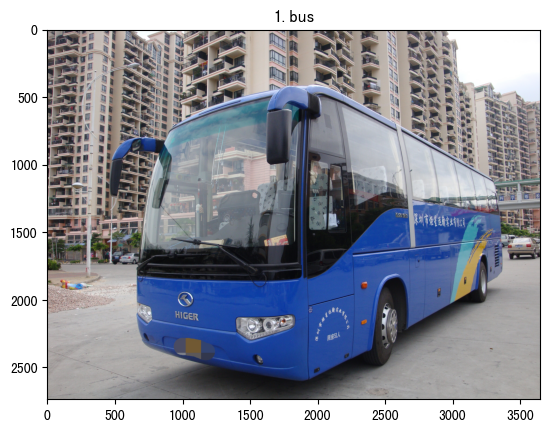

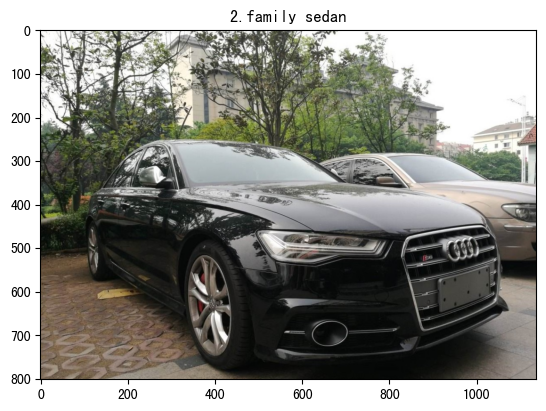

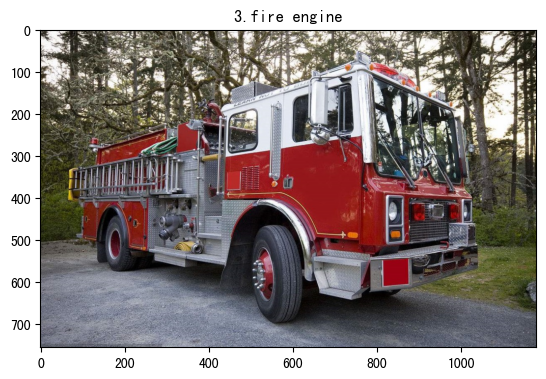

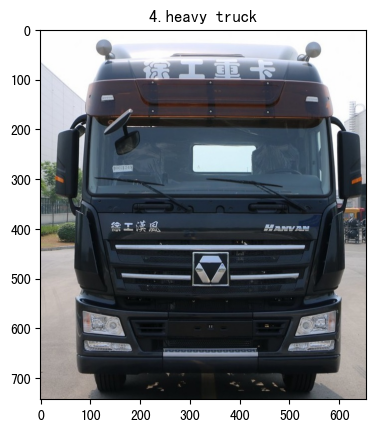

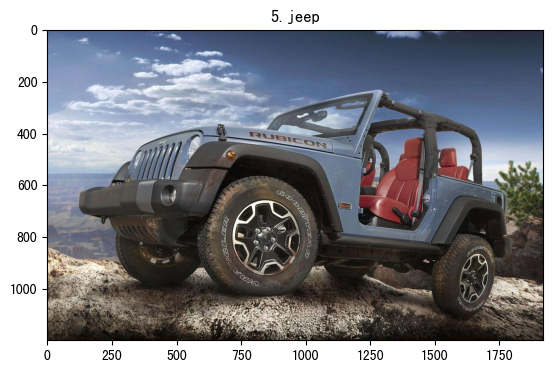

In [2]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
import pathlib
from mindspore import set_seed

seed = 1234
set_seed(seed)
#  定义数据集路径
data_path = pathlib.Path('/home/jovyan/work/datasets/6892b1909e78856c69427a84-momodel/train')


def ShowImage(path,title):
    img = Image.open(path)
    img_np = np.array(img)
    plt.imshow(img_np)
    plt.title(title)
    plt.show()
    return
ShowImage(data_path.joinpath("bus/024017bda63bf980f932736ced0daa17.jpg"),"1.bus")
ShowImage(data_path.joinpath("family sedan/0142c36b53a35696295edd28c890c26d.jpg"),"2.family sedan")
ShowImage(data_path.joinpath("fire engine/01fb2fd802b56ca6c39078adcc40324b.jpg"),"3.fire engine")
ShowImage(data_path.joinpath("heavy truck/014e01224e88abb52851cce801c7db0a.jpg"),"4.heavy truck")
ShowImage(data_path.joinpath("jeep/004da428af4c7436b5f1caa2d06fe2c5.jpg"),"5.jeep")

## 2. 数据集分析和可视化

### 2.1 数据集大小及各种类构成分析

In [3]:
import os
from PIL import Image
import numpy as np
image = []
label = []
count = {}
shape = []
for root,dirs,files in os.walk(data_path):
    for name in dirs:
        print(name)
        for root1,dirs1,files1 in os.walk(os.path.join(data_path,name)):
            for name1 in files1:
                img = Image.open(os.path.join(data_path,name,name1))
                img_np = np.array(img)
                label.append(name)
                if  name not in count:
                    count[name]=0
                count[name] += 1
                shape.append(img_np.shape)
                print(img_np.shape)


bus
(2736, 3648, 3)
(741, 1030, 3)
(682, 1313, 3)
(660, 1390, 3)
(533, 800, 3)
(768, 1024, 3)
(2448, 3264, 3)
(683, 1257, 3)
(768, 1024, 3)
(645, 1073, 3)
(716, 1023, 3)
(793, 1000, 3)
(576, 1024, 3)
(709, 1332, 3)
(1200, 1600, 3)
(691, 1116, 3)
(768, 1024, 3)
(818, 1240, 3)
(658, 1069, 3)
(705, 1222, 3)
(1576, 2816, 3)
(768, 1024, 3)
(1200, 1600, 3)
(2356, 3534, 3)
(2705, 3648, 3)
(768, 1024, 3)
(698, 1021, 3)
(764, 1502, 3)
(682, 1024, 3)
(638, 1294, 3)
(2448, 3264, 3)
(792, 1014, 3)
(813, 1257, 3)
(1446, 2576, 3)
(738, 1024, 3)
(800, 1200, 3)
(609, 946, 3)
(561, 937, 3)
(1666, 2499, 3)
(768, 1024, 3)
(960, 1280, 3)
(540, 960, 3)
(824, 1357, 3)
(768, 1024, 3)
(655, 979, 3)
(576, 1024, 3)
(576, 1024, 3)
(749, 1350, 3)
(764, 1131, 3)
(748, 1247, 3)
(2152, 3750, 3)
(518, 1064, 3)
(704, 975, 3)
(602, 1069, 3)
(1536, 2048, 3)
(1013, 1350, 3)
(3264, 4928, 3)
(2112, 2816, 3)
(1536, 2048, 3)
(1536, 2048, 3)
(1944, 2592, 3)
(682, 1064, 3)
(960, 1280, 3)
(999, 1265, 3)
(2592, 3456, 3)
(1090, 1

In [4]:
pic_sum = 0
for key in count:
    pic_sum += count[key]
print("图片总数：", pic_sum)
for key in count:
    print("类别:",key,"数量:",count[key])

图片总数： 1400
类别: bus 数量: 140
类别: family sedan 数量: 140
类别: fire engine 数量: 140
类别: heavy truck 数量: 140
类别: jeep 数量: 140
类别: minibus 数量: 140
类别: racing car 数量: 140
类别: SUV 数量: 140
类别: taxi 数量: 140
类别: truck 数量: 140


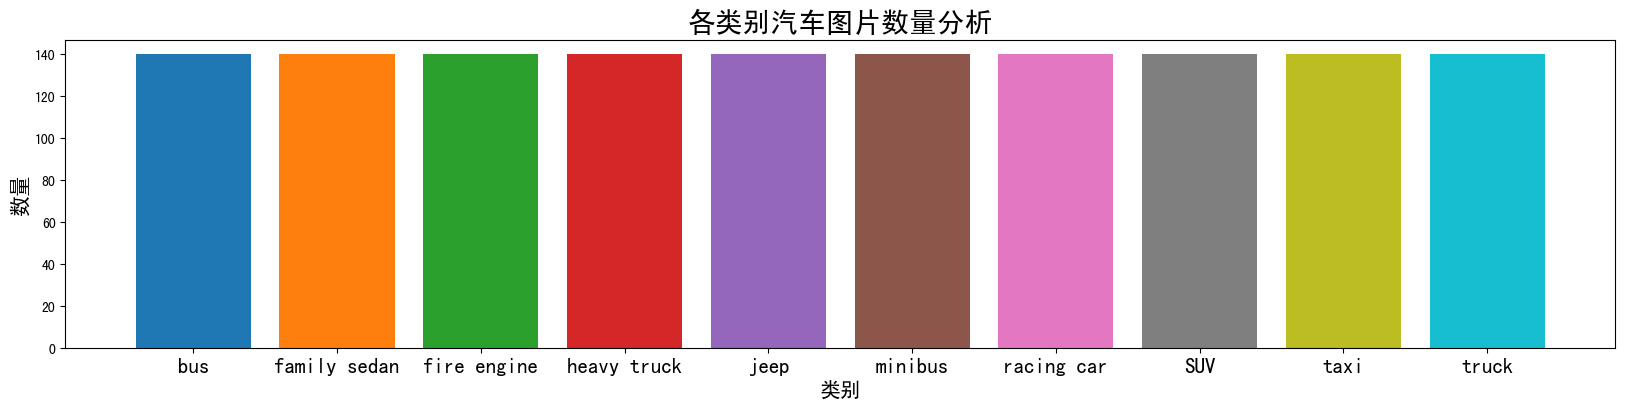

In [5]:
from matplotlib import pyplot as plt

fig =plt.figure(figsize = (20,4))
plt.title("各类别汽车图片数量分析",fontsize=20)
plt.xlabel("类别",fontsize = 15)
plt.ylabel("数量",fontsize = 15)
plt.xticks(fontsize = 15)
for key in count:
    plt.bar(key,count[key])
plt.show()

### 2.2 图片形状构成分析

In [6]:
for i in range(5):
    print(shape[i])
    print(len(shape[i]))

(2736, 3648, 3)
3
(741, 1030, 3)
3
(682, 1313, 3)
3
(660, 1390, 3)
3
(533, 800, 3)
3


由此可见，图片的长、宽不一定相同，且通道数通常为 3.  
先检查所有图片是否正常，标准是由 3 维构成，长、宽在 10-10000 间，通道数为 3

In [7]:
for i in range(len(shape)):
    num = i
    i = shape[i]
    if len(i)!=3 or i[0]<10 or i[0] > 10000 or i[1]<10 or i[1]>10000 or i[2]!=3:
        print(num,i)

1378 (688, 750)


发现一张不合要求的图片，后续数据集载入时排除该图片

根据各种图片的形状绘制散点图

0


/tmp/ipykernel_191/2016166897.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x_dict[key],y_dict[key],s=10,color=([color[num]]*len(x_dict[key])),cmap='viridis')


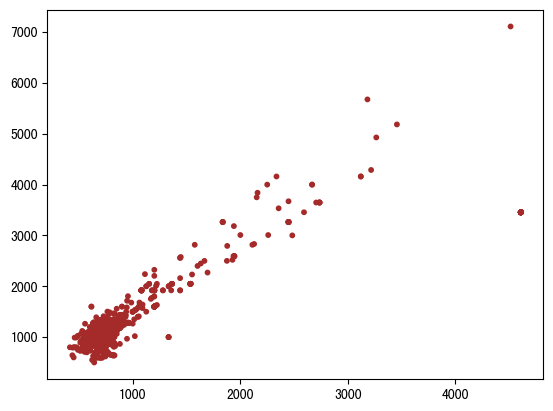

In [8]:
x_dict = {}
y_dict = {}
color = ['brown']*10
for i in range(len(label)) :
    if label[i] not in x_dict.keys() :
        x_dict[label[i]] = []
        y_dict[label[i]] = []
    x_dict[label[i]].append(shape[i][0])
    y_dict[label[i]].append(shape[i][1])
num = 0
print(num)
for key in x_dict:
    plt.scatter(x_dict[key],y_dict[key],s=10,color=([color[num]]*len(x_dict[key])),cmap='viridis')
    num += 1
plt.show()
    

根据散点图可知，图像的形状分布集中在 x：y 为 2: 3 的直线周围。同时，大部分图像的长宽像素点都较多。  
为方便模型训练，考虑将图像统一处理成同一尺度。为加快模型训练速度，减小输入图像占用内存，考虑将图像缩放到一个较小尺度。  
为减小图形处理造成的信息损失，处理完的图像长宽比采用 x: y = 2: 3，与大部分原始图像的长宽比较接近。  
为避免拉伸使得图像变形，可以先将图像填充为特定长宽比，然后再进行缩放。

下面对图片集进行处理

In [9]:
import os
from PIL import Image
import numpy as np

image = []
label = []
count = {}
shape = []
for root,dirs,files in os.walk(data_path):
    for name in dirs:
        print(name)
        for root1,dirs1,files1 in os.walk(os.path.join(data_path,name)):
            for name1 in files1:
                img = Image.open(os.path.join(data_path,name,name1))
                img_np = np.array(img)
                i = img_np.shape
                if len(i)!=3 or i[0]<10 or i[0] > 10000 or i[1]<10 or i[1]>10000 or i[2]!=3:
                    pass
                else :
                    label.append(name)
                    size = 0;
                    width,height = img.size
                    if width//3 + 1 > size:
                        size = width//3 + 1
                    if height//2 + 1 > size:
                        size = height//2 + 1
                    new_img = Image.new(img.mode,(size*3,size*2))
                    new_img.paste(img,(size*3 - width,size*2 - height))
                    new_img=new_img.resize((600,400))
                    img_np = np.array(new_img)
                    image.append(img_np)
print("end")

bus
family sedan
fire engine
heavy truck
jeep
minibus
racing car
SUV
taxi
truck
end


将图片与标签数据以numpy形式分别存储在文件夹中，以便后续使用时直接读取

In [10]:
import numpy as np
from mindspore import dataset as ds
image_np = np.array(image)
np.save("train data",image_np)
label_np = np.array(label)
np.save("label",label_np)

读取图片与标签数据

In [11]:
import numpy as np
image_np = np.load("train data.npy")
label_np = np.load("label.npy")
print(image_np.shape)
print(label_np)

(1399, 400, 600, 3)
['bus' 'bus' 'bus' ... 'truck' 'truck' 'truck']


将标签转化为整数



In [12]:
label_num = []
count = -1
for i in range(len(label_np)):
    if i ==0 or label_np[i]!=label_np[i-1]:
        count = count + 1
        print(label_np[i],count)
    label_num.append(count)
label_num = np.array(label_num)
print(label_num.dtype)
print(label_num.shape)

bus 0
family sedan 1
fire engine 2
heavy truck 3
jeep 4
minibus 5
racing car 6
SUV 7
taxi 8
truck 9
int64
(1399,)


按8:2划分训练集和测试集

In [13]:
train_data = []
train_label = []
test_data = []
test_label = []

for i in range(len(image_np)):
    if i % 5 == 0:
        test_data.append(image_np[i])
        test_label.append(label_num[i])
    else:
        train_data.append(image_np[i])
        train_label.append(label_num[i])
print(len(train_data),len(train_label),len(test_data),len(test_label))

1119 1119 280 280


将数据集转化为 dataset 格式，同时对数据进行预处理。  
包括 type_cast_op 操作，将标签转化为 int32;  
resize_op 操作，将图片处理成 128x64 大小，减小网络运算量的同时保留一定的图片精度；  
Rescale 操作，将图片像素归一化处理，方便训练时的运算；  
HWC2CHW 操作，将图片由高x宽x通道数变为通道数x高x宽，这是后续构建网络时卷积层传参的要求。  
之后进行 shuffle 混洗，打乱数据顺序，再以 128 为 batch 进行打包，每次将 128 个数据一同送入模型进行训练。

In [14]:
from mindspore import dataset as ds
from mindspore.dataset import transforms
import mindspore.dataset.vision as CV
from mindspore.dataset.vision import Inter
from mindspore import dtype as mstype
import mindspore.dataset.transforms.transforms as C

class MyDataset:
    def __init__(self,data,label):
        self.data = data
        self.label = label
    def __getitem__(self,index):
        return self.data[index],self.label[index]
    def __len__(self):
        return len(self.data)

def get_dataset(data,label,batch_size=128,class_num = 10):
    dataset_generator = MyDataset(data,label)
    dataset = ds.GeneratorDataset(source=dataset_generator,column_names = ["data","label"])
    #onehot_op = transforms.OneHot(num_classes = class_num)
    resize_op = CV.Resize((128,64),interpolation = Inter.LINEAR)
    rescale_op = CV.Rescale(1.0/255.0,0)
    hwc2chw_op = CV.HWC2CHW()
    type_cast_op = C.TypeCast(mstype.int32)
    
    
    #dataset = dataset.map(operations = onehot_op,input_columns = "label")
    dataset = dataset.map(operations = type_cast_op, input_columns="label")
    dataset = dataset.map(operations = [resize_op, rescale_op, hwc2chw_op],input_columns = "data")

    dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size,drop_remainder = True)
    return dataset
train_label = np.array(train_label)
train_data = np.array(train_data)
train_set = get_dataset(train_data,train_label)
test_set = get_dataset(test_data,test_label)
print("end")

end


检查图片是否完整，标签是否正确

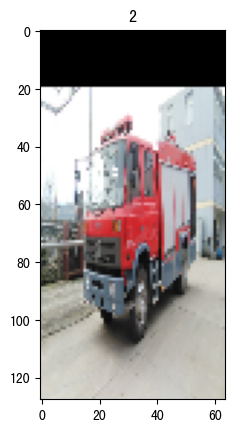

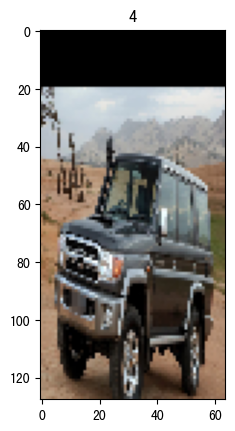

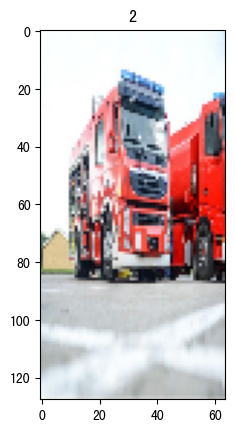

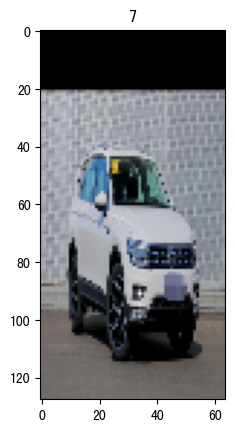

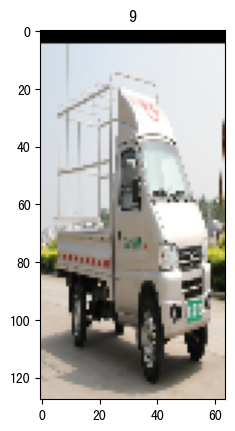

In [15]:
from matplotlib import pyplot as plt

dict = train_set.create_dict_iterator()
for i in range(5):
    item = next(dict)
    img = item['data'].asnumpy()
    img = img[0].transpose(1,2,0)
    plt.imshow(img)
    plt.title(item['label'][0])
    plt.show()

## 3. 模型构建

In [16]:
from mindspore import context
context.set_context(mode = context.GRAPH_MODE,device_target = "CPU")

### 3.1 模型定义

模型构建说明：  
1. 主要以卷积层+全连接层结合的方式构建模型。 开始图片尺寸较大，如果直接用全连接层可能导致参数过多，所以可以先使用卷积层，起到提取图片特征的效果。  
   使用卷积层后利用最大池化强化特征并缩小图片尺寸。经过 4 层卷积+池化后图片缩小到 8x4 ，在这样一个尺度下可以使用全连接层进行后期处理。经过 2 个全连接层后输出。  
2. 每次卷积层之后采用正则化处理，起到减少过拟合的作用
3. 第 2、3、4 层卷积和第 1 层全连接层加入了 dropout 层，在训练过程中随机停止一部分神经元的工作，能够减少过拟合。
4. 每层卷积层的输出通道逐倍增加，这是因为每层卷积层输入的图片尺寸逐倍减小，这样可以使得不同卷积层在计算量上达到平衡。
5. 4 个卷积层和第一个全连接层后加`Relu`函数，使得整个模型非线性化，提高模型的拟合能力。

模型结构如下：


<img src = 'https://imgbed.momodel.cn/79adb8d15420a08285b1efc86b269eab.png' width=1500 >

模型定义如下

In [17]:
from mindspore import nn
class Mynet(nn.Cell):
    def __init__(self, num_class=10, num_channel=3):
        super(Mynet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 3, pad_mode='same')
        self.norm1 = nn.BatchNorm2d(num_features = 6)
        
        self.conv2 = nn.Conv2d(6, 12, 5, pad_mode='same')
        self.norm2 = nn.BatchNorm2d(num_features = 12)
        
        self.conv3 = nn.Conv2d(12,24,5,pad_mode = 'same')
        self.norm3 = nn.BatchNorm2d(num_features = 24)
        
        self.conv4 = nn.Conv2d(24, 48, 3, pad_mode='same')
        self.norm4 = nn.BatchNorm2d(num_features = 48)
        
        self.fc1 = nn.Dense(48 * 4 * 8, 128)
        self.fc2 = nn.Dense(128,num_class)
        self.relu = nn.ReLU()
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p = 0.3)
        
        self.softmax = nn.Softmax()
    def construct(self, x):
        x = self.relu(self.norm1(self.conv1(x)))
        x = self.max_pool2d(x)
        
        x = self.dropout(self.relu(self.norm2(self.conv2(x))))
        x = self.max_pool2d(x)
        
        x = self.dropout(self.relu(self.norm3(self.conv3(x)))) 
        x = self.max_pool2d(x)
        
        x = self.dropout(self.relu(self.norm4(self.conv4(x)))) 
        x = self.max_pool2d(x)
        
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

network = Mynet()
for param in network.get_parameters():
    print(param.shape,param.size)
print(network)

(6, 3, 3, 3) 162
(6,) 6
(6,) 6
(6,) 6
(6,) 6
(12, 6, 5, 5) 1800
(12,) 12
(12,) 12
(12,) 12
(12,) 12
(24, 12, 5, 5) 7200
(24,) 24
(24,) 24
(24,) 24
(24,) 24
(48, 24, 3, 3) 10368
(48,) 48
(48,) 48
(48,) 48
(48,) 48
(128, 1536) 196608
(128,) 128
(10, 128) 1280
(10,) 10
Mynet<
  (conv1): Conv2d<input_channels=3, output_channels=6, kernel_size=(3, 3), stride=(1, 1), pad_mode=same, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0x7f33dad44d60>, bias_init=None, format=NCHW>
  (norm1): BatchNorm2d<num_features=6, eps=1e-05, momentum=0.9, gamma=Parameter (name=norm1.gamma, shape=(6,), dtype=Float32, requires_grad=True), beta=Parameter (name=norm1.beta, shape=(6,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=norm1.moving_mean, shape=(6,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=norm1.moving_variance, shape=(6,), dtype=Float32, requires_grad=False)>
  (conv2): Conv2d<input_channels

### 3.2 损失器和优化器定义
学习率设定为 0.005  
使用交叉熵作为损失函数  
使用 Momentum 作为优化器  

In [18]:
import mindspore.nn as nn
from mindspore.nn import SoftmaxCrossEntropyWithLogits

lr = 0.005
momentum = 0.9 
network = Mynet()

net_opt = nn.Momentum(network.trainable_params(), lr, momentum)

net_loss = SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

## 4. 模型训练

### 4.1 训练部分代码
完整 python 训练脚本存储于路径： `/home/jovyan/work/car_classifier/train.py`  
在 GPU 环境中运行 `train.py` 文件  
模型权重存储于路径：`/home/jovyan/work/results`  


In [19]:
import os
from mindspore import Tensor, Model
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor
from mindspore.nn import Accuracy
from mindspore.train.callback import ModelCheckpoint,LossMonitor
from mindspore import context

epoch_size = 150
model_path = "/home/jovyan/work/results/checkpoint"
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
os.system('rm -f {0}*.ckpt {0}*.meta {0}*.pb'.format(model_path))
train_set = get_dataset(train_data,train_label)
model = Model(network, net_loss, net_opt, metrics={"Accuracy": Accuracy()} )
ckpt_cb = ModelCheckpoint(directory = model_path)
loss_cb = LossMonitor(5)

model.train(epoch_size, train_set, callbacks=[ckpt_cb,loss_cb], dataset_sink_mode=False)

### 4.2 加载模型并推理

[ERROR] CORE(191,7f3434183740,python):2025-08-06-15:56:27.175.563 [mindspore/core/utils/file_utils.cc:253] GetRealPath] Get realpath failed, path[/tmp/ipykernel_191/1216685025.py]
[WARNING] CORE(191,7f3434183740,python):2025-08-06-15:56:27.175.612 [mindspore/core/utils/info.cc:120] ToString] The file '/tmp/ipykernel_191/1216685025.py' may not exists.


Predicted: "[4 4 4 4 4 4 4 4 4 4]", Actual: "[0 5 9 8 1 5 3 6 9 3]"


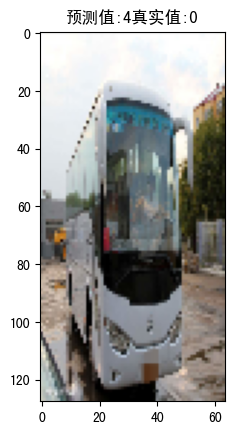

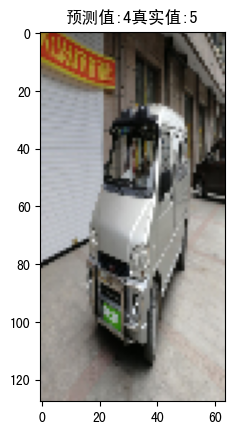

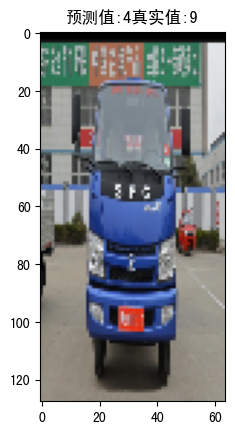

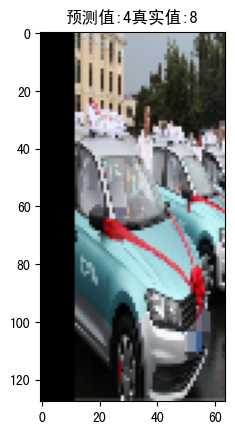

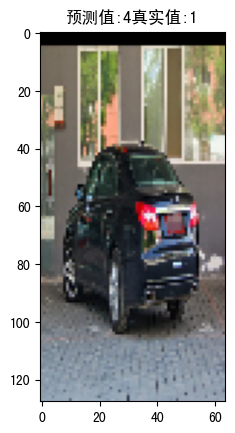

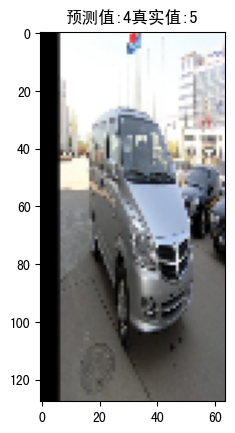

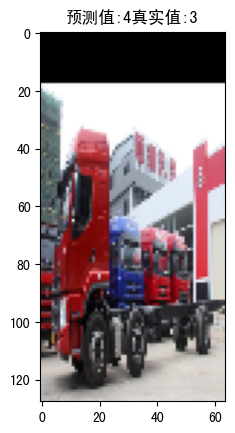

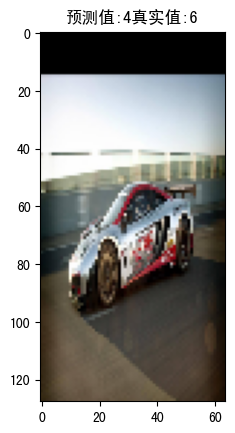

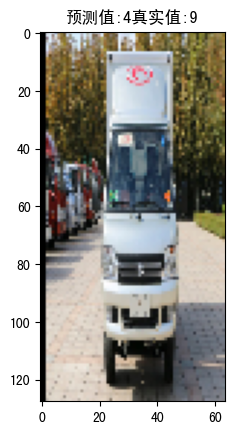

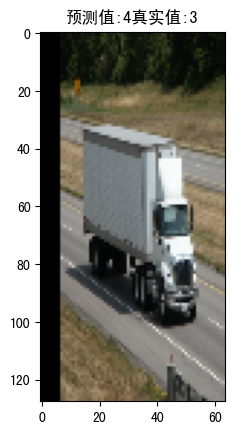

In [20]:
from matplotlib import pyplot as plt
from mindspore import load_checkpoint, load_param_into_net

network = Mynet()
#可以把 CKP_2-1_2.ckpt 更新成最新的模型文件
param_dict = load_checkpoint("/home/jovyan/work/results/checkpoint/CKP_2-1_2.ckpt")
load_param_into_net(network, param_dict)
network.set_train(False)
test_set = get_dataset(test_data,test_label)
dict = test_set.create_dict_iterator()
item = next(dict)
data = item['data']
label = item['label']
pred = network(data)
predicted = pred.argmax(1)
print(f'Predicted: "{predicted[:10]}", Actual: "{label[:10]}"')
for i in range(10):
    plt.imshow(data[i].transpose(1,2,0).asnumpy())
    plt.title("预测值:"+str(predicted[i])+"真实值:"+str(label[i]))
    plt.show()
        

如图所示，10 张图片中，第 1、2、3、4、6、7、10 张图片预测正确，其余预测错误

## 5. 模型评估

Accuracy 评估与改进方向

In [21]:
from mindspore import load_checkpoint, load_param_into_net
from mindspore import Tensor, Model
from mindspore.nn import Accuracy
import mindspore.nn as nn
from mindspore.nn import SoftmaxCrossEntropyWithLogits

#  加载模型权重
network = Mynet()
#可以把 CKP_2-1_2.ckpt 更新成最新的模型文件
param_dict = load_checkpoint("/home/jovyan/work/results/checkpoint/CKP_2-1_2.ckpt")
load_param_into_net(network, param_dict)

#  构建模型
lr = 0.005
momentum = 0.9 
net_opt = nn.Momentum(network.trainable_params(), lr, momentum)
net_loss = SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
model = Model(network, net_loss, net_opt, metrics={"Accuracy": Accuracy()})

#  计算模型在训练集与测试集上的指标
train_set = get_dataset(train_data,train_label)
test_set = get_dataset(test_data,test_label)
acc = model.eval(train_set, dataset_sink_mode=False)
print("train accuracy:{}".format(acc))
acc = model.eval(test_set, dataset_sink_mode=False)
print("test accuracy:{}".format(acc))

[WARNING] MD(191,7f322bff7700,python):2025-08-06-15:56:36.310.118 [mindspore/ccsrc/minddata/dataset/engine/datasetops/batch_op.cc:116] operator()] Memory consumption is more than 87.3589%, which may cause OOM. Please reduce num_parallel_workers size / optimize 'per_batch_map' function / other python data preprocess function to reduce memory usage.


train accuracy:{'Accuracy': 0.0927734375}


[WARNING] MD(191,7f322dffb700,python):2025-08-06-15:56:44.295.767 [mindspore/ccsrc/minddata/dataset/engine/datasetops/batch_op.cc:116] operator()] Memory consumption is more than 89.2657%, which may cause OOM. Please reduce num_parallel_workers size / optimize 'per_batch_map' function / other python data preprocess function to reduce memory usage.


test accuracy:{'Accuracy': 0.10546875}


## 6. 模型改进

1. 训练结束时损失值已经小于 0.02，模型在训练集上的精确度为 0.98，但在测试集上只有 0.66，说明可能出现了过拟合   
2. 从数据集的角度讲，可以尝试用数据增强的方式增加图片数目，或者在图片`resize`时增大其像素个数保留更多原始信息，避免过拟合   
3. 从网络构建的角度讲，可以尝试通过增加残差结构增大模型深度，改变最大池为平均化池等方法调整网络结构   
4. 从网络参数的角度讲，4 个卷积层的卷积核大小普遍较小，可能造成感受野范围小的问题，可以考虑增大卷积核数目或者增大卷积层深度；为减少过拟合，可以考虑减小各层网络的参数量；学习率、 batch_size 等参数也可适当调整